In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

#import everything we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import torch

print("All libraries imported")

Mounted at /content/drive
All libraries imported


In [2]:
# Load Data
csv_path = '/content/drive/MyDrive/hx_project/heat_exchanger_dataset.csv'

#Load
df = pd.read_csv(csv_path)

print("=" * 50)
print("DATA OVERVIEW")
print("=" * 50)
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print("\nColumn names:")
for i, col in enumerate(df.columns, 1):
  print(f" {i}. {col}")

print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

DATA OVERVIEW
Total rows: 10000
Total columns: 20

Column names:
 1. hot_inlet_temperature_k
 2. cold_inlet_mass_flow_kg_s
 3. hot_outlet_temperature_k
 4. cold_outlet_temperature_k
 5. hx_1_heat_load_kw
 6. hot_outlet_pressure_pa
 7. cold_outlet_pressure_pa
 8. hot_outlet_mass_flow_kg_s
 9. cold_outlet_mass_flow_kg_s
 10. hx_1_logarithmic_mean_temperature_difference_lmtd_k
 11. hot_inlet_temperature_k_noisy
 12. cold_inlet_mass_flow_kg_s_noisy
 13. hot_outlet_temperature_k_noisy
 14. cold_outlet_temperature_k_noisy
 15. hx_1_heat_load_kw_noisy
 16. hot_outlet_pressure_pa_noisy
 17. cold_outlet_pressure_pa_noisy
 18. hot_outlet_mass_flow_kg_s_noisy
 19. cold_outlet_mass_flow_kg_s_noisy
 20. hx_1_logarithmic_mean_temperature_difference_lmtd_k_noisy

First 5 rows:
   hot_inlet_temperature_k  cold_inlet_mass_flow_kg_s  \
0                   373.15                   0.500000   
1                   373.15                   0.545455   
2                   373.15                   0.590909   


STATISTICAL SUMMARY
       hot_inlet_temperature_k  cold_inlet_mass_flow_kg_s  \
count             10000.000000               10000.000000   
mean                473.150000                   2.750000   
std                  58.318244                   1.312160   
min                 373.150000                   0.500000   
25%                 423.150000                   1.624998   
50%                 473.150000                   2.750000   
75%                 523.150000                   3.875002   
max                 573.150000                   5.000000   

       hot_outlet_temperature_k  cold_outlet_temperature_k  hx_1_heat_load_kw  \
count              10000.000000               1.000000e+04       10000.000000   
mean                 367.671937               2.011510e+03         107.661325   
std                    4.571133               1.098270e-10          19.243081   
min                  359.837000               2.011510e+03          61.395900   
25%                  363

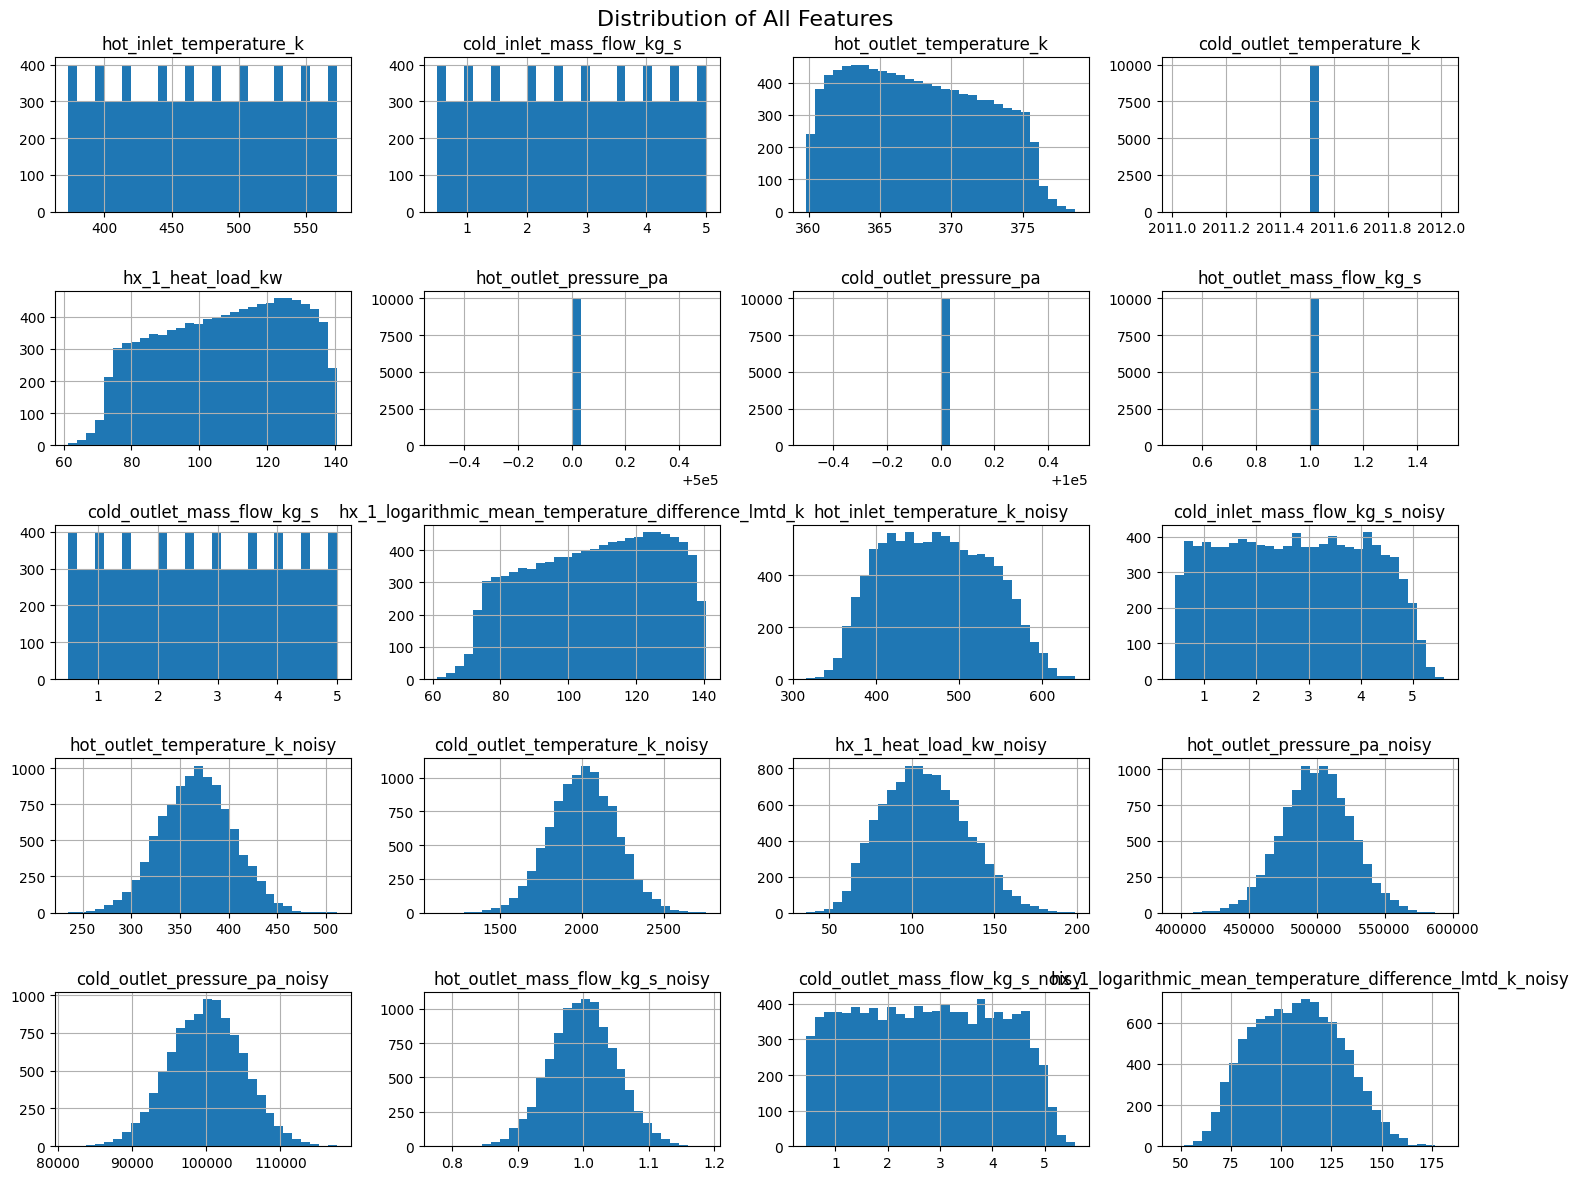

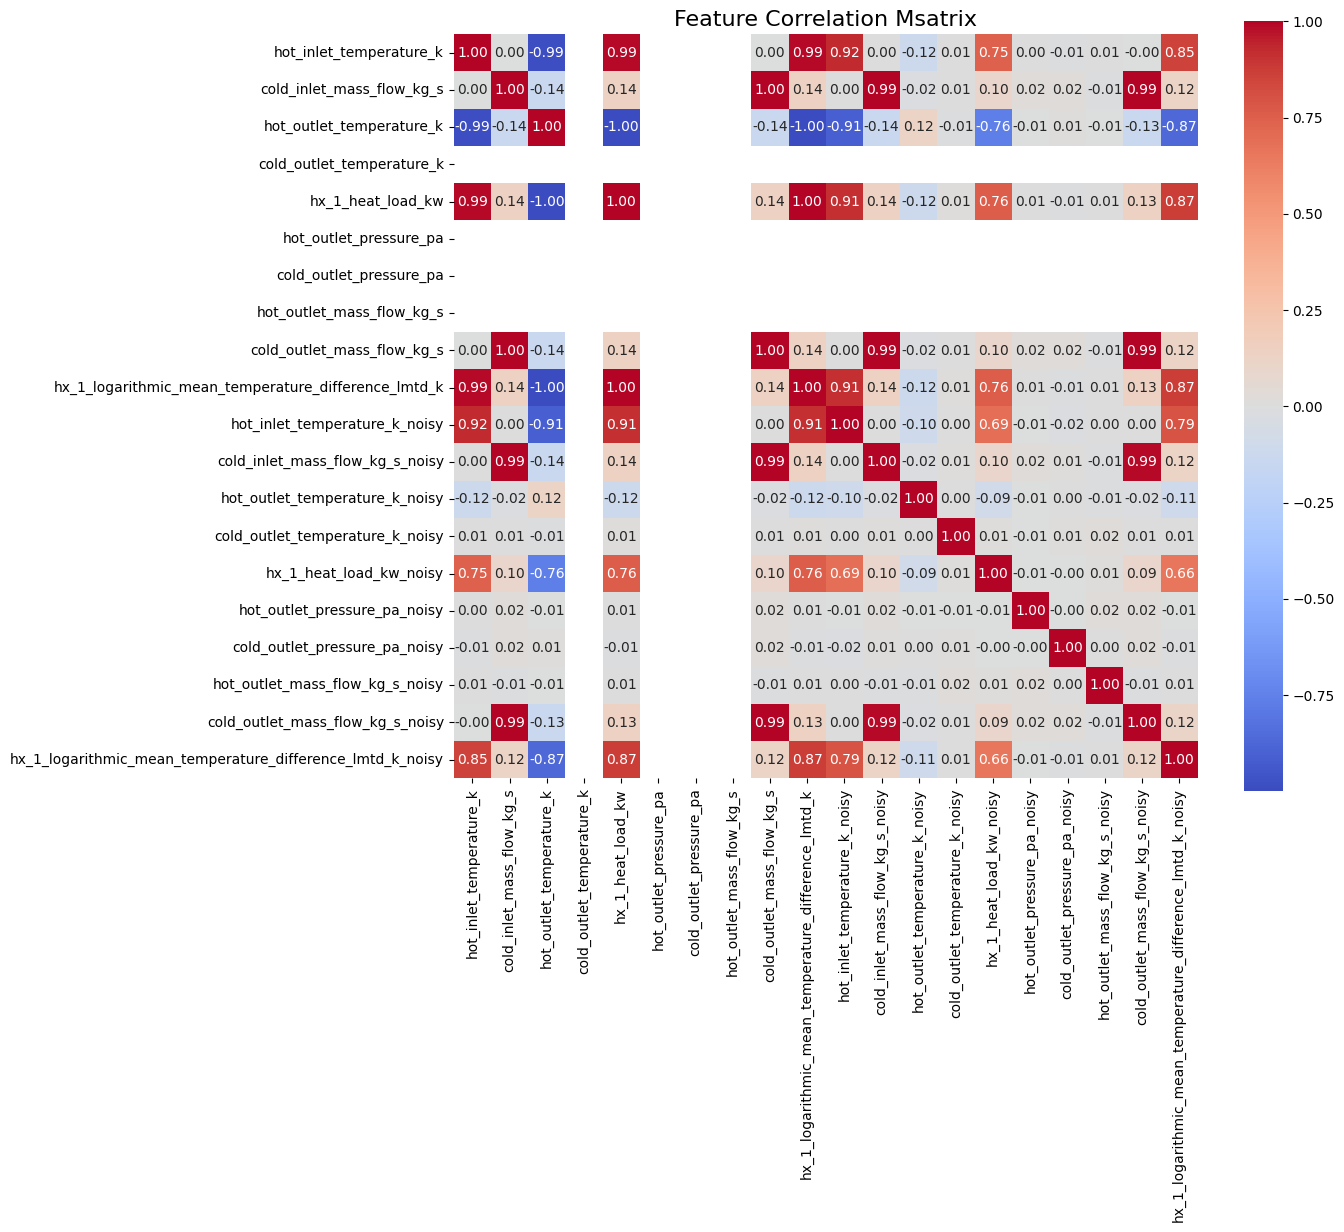


CORRELATION WITH EACH COLUMN
hot_inlet_temperature_k                  -0.9851
cold_inlet_mass_flow_kg_s                -0.1357
cold_outlet_temperature_k                0.0000
hx_1_heat_load_kw                        -1.0000
hot_outlet_pressure_pa                   nan
cold_outlet_pressure_pa                  nan
hot_outlet_mass_flow_kg_s                nan
cold_outlet_mass_flow_kg_s               -0.1357
hx_1_logarithmic_mean_temperature_difference_lmtd_k -1.0000
hot_inlet_temperature_k_noisy            -0.9107
cold_inlet_mass_flow_kg_s_noisy          -0.1360
hot_outlet_temperature_k_noisy           0.1245
cold_outlet_temperature_k_noisy          -0.0079
hx_1_heat_load_kw_noisy                  -0.7582
hot_outlet_pressure_pa_noisy             -0.0058
cold_outlet_pressure_pa_noisy            0.0104
hot_outlet_mass_flow_kg_s_noisy          -0.0058
cold_outlet_mass_flow_kg_s_noisy         -0.1343
hx_1_logarithmic_mean_temperature_difference_lmtd_k_noisy -0.8679


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [3]:
# Exploratory Data Analysis (EDA)

# 1. Statistics
print("\n" + "=" * 50)
print("STATISTICAL SUMMARY")
print("=" * 50)
print(df.describe())

# 2. Visualize distributions
df.hist(figsize=(15, 12), bins=30)
plt.suptitle("Distribution of All Features", fontsize=16)
plt.tight_layout()
plt.show()

# 3. Correlation matrix
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title("Feature Correlation Msatrix", fontsize=16)
plt.show()

# What's our target?
# Look at the correlation and decide
print("\n" + "=" * 50)
print("CORRELATION WITH EACH COLUMN")
print("=" * 50)
for col in df.columns:
  if col != 'hot_outlet_temperature_k': # we can change this to our tagret
     corr = df["hot_outlet_temperature_k"].corr(df[col])
     print(f"{col:40s} {corr:.4f}")

In [4]:
# Defining Features and Target
# Define X (inputs) AND y (target)

Target = 'hot_outlet_temperature_k'

# what colums use to predict?
FEATURES = [
    'hot_inlet_temperature_k_noisy',
    'cold_inlet_mass_flow_kg_s_noisy',
    'hot_outlet_pressure_pa_noisy',
    'cold_outlet_pressure_pa_noisy',
    'hot_outlet_mass_flow_kg_s_noisy',
    'cold_outlet_mass_flow_kg_s_noisy',
    'hot_outlet_temperature_k_noisy'
]

print("=" * 50)
print("FEATURES AND TARGET")
print("=" * 50)
print(f"Target variable: {Target}")
print(f"Features: ({len(FEATURES)}):")
for i, f in enumerate(FEATURES, 1):
  print(f" {i}. {f}")

# Check if columns exist
missing = [f for f in FEATURES if f not in df.columns]
if missing:
  print(f"\nx Missing columns: {missing}")
  print(f"Available columns: {df.columns.tolist()}")
else:
    print("\nAll features found!")

# Prepare X and y
X = df[FEATURES]
y = df[Target]

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

FEATURES AND TARGET
Target variable: hot_outlet_temperature_k
Features: (7):
 1. hot_inlet_temperature_k_noisy
 2. cold_inlet_mass_flow_kg_s_noisy
 3. hot_outlet_pressure_pa_noisy
 4. cold_outlet_pressure_pa_noisy
 5. hot_outlet_mass_flow_kg_s_noisy
 6. cold_outlet_mass_flow_kg_s_noisy
 7. hot_outlet_temperature_k_noisy

All features found!

X shape: (10000, 7)
y shape: (10000,)


In [5]:
# Split Data (Train/Test)
# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("=" * 50)
print("DATA SPLIT")
print("=" * 50)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"\nFeatures in training: {X_train.shape[1]}")


DATA SPLIT
Training set: 8000 samples
Testing set: 2000 samples

Features in training: 7


In [6]:
# Scale the Data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=" * 50)
print("DATA SCALING")
print("=" * 50)
print("Trainig data scaled")
print(f"Mean: {X_train_scaled.mean():.4f}")
print(f"Std: {X_train_scaled.std():.4f}")
print("Test data scaled using training scaler")


DATA SCALING
Trainig data scaled
Mean: 0.0000
Std: 1.0000
Test data scaled using training scaler


In [7]:
# Training first model (Linear Regression)
# Model 1: LINEAR REGRESSION

print("\n" + "=" * 50)
print("TRAINING LINEAR REGRESSION MODEL")
print("=" * 50)

# Create model
lr_model = LinearRegression()

# Train
lr_model.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_scaled)

#Evaluate
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression Results:")
print(f"MAE: {mae_lr:.4f} K")
print(f"RMSE: {rmse_lr:.4f} K")
print(f" R2: {r2_lr:.4f}")

# Coefficients (which features matter most?)
coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': lr_model.coef_
})
coef_df['Abs'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Abs', ascending=False)

print("\nFeature Importance (by coefficient):")
for i, row in coef_df.iterrows():
    print(f"   {row['Feature']:40s} → {row['Coefficient']:.4f}")



TRAINING LINEAR REGRESSION MODEL
Linear Regression Results:
MAE: 1.4036 K
RMSE: 1.7691 K
 R2: 0.8510

Feature Importance (by coefficient):
   hot_inlet_temperature_k_noisy            → -4.1465
   cold_inlet_mass_flow_kg_s_noisy          → -0.4932
   hot_outlet_temperature_k_noisy           → 0.1307
   cold_outlet_mass_flow_kg_s_noisy         → -0.1152
   hot_outlet_pressure_pa_noisy             → -0.0343
   hot_outlet_mass_flow_kg_s_noisy          → -0.0311
   cold_outlet_pressure_pa_noisy            → -0.0094


In [8]:
# Train the better model (Random Forest)
print("\n" + "=" * 60)
print("Training RANDOM FOREST MODEL")
print("=" * 60)

 # Create Model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
 )

# Train
rf_model.fit(X_train, y_train)   # Random Forest doesn't need scaling

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Results:")
print(f"MAE: {mae_rf:.4f} K")
print(f"RMSE: {rmse_rf:.4f} K")
print(f" R2: {r2_rf:.4f}")

#Feature importance
importance_rf = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance (Random Forest):")
for i, row in importance_rf.iterrows():
  print(f"{row['Feature']:40s} → {row['Importance']:.4f}")


Training RANDOM FOREST MODEL
Random Forest Results:
MAE: 1.3128 K
RMSE: 1.6559 K
 R2: 0.8695

Feature Importance (Random Forest):
hot_inlet_temperature_k_noisy            → 0.9219
cold_inlet_mass_flow_kg_s_noisy          → 0.0226
cold_outlet_mass_flow_kg_s_noisy         → 0.0190
hot_outlet_temperature_k_noisy           → 0.0095
hot_outlet_pressure_pa_noisy             → 0.0092
hot_outlet_mass_flow_kg_s_noisy          → 0.0091
cold_outlet_pressure_pa_noisy            → 0.0088


In [9]:
# Model 3: XGBOOST (Usually the Best)
print("\n" + "=" * 50)
print("TRAINING XGBOOST")
print("=" * 50)

# Create Model
xgb_model = xgb.XGBRegressor(
    n_estimators=200,    # Number of trees
    max_depth=5,         # Tree depth
    learning_rate=0.05,  # How fast to learn
    subsample=0.8,       # Fraction of data used per tree
    colsample_bytree=0.8,  # Fraction of features used per tree
    random_state=42,
    n_jobs=-1
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Results:")
print(f"MAE: {mae_xgb:.4f} K")
print(f"RMSE: {rmse_xgb:.4f} K")
print(f" R2: {r2_xgb:.4f}")

# Feature importance
importance_xgb = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance (XGBoost):")
for i, row in importance_xgb.iterrows():
  print(f"{row['Feature']:40s} {row['Importance']:.4f}")


TRAINING XGBOOST
XGBoost Results:
MAE: 1.2923 K
RMSE: 1.6307 K
 R2: 0.8734

Feature Importance (XGBoost):
hot_inlet_temperature_k_noisy            0.8899
cold_outlet_mass_flow_kg_s_noisy         0.0300
cold_inlet_mass_flow_kg_s_noisy          0.0285
hot_outlet_temperature_k_noisy           0.0177
hot_outlet_mass_flow_kg_s_noisy          0.0122
cold_outlet_pressure_pa_noisy            0.0111
hot_outlet_pressure_pa_noisy             0.0105



MODEL COMPARISON
            Model  MAE (K)  RMSE (K)       R²
Linear Regression 1.403602  1.769086 0.850993
    Random Forest 1.312761  1.655873 0.869455
          XGBoost 1.292324  1.630703 0.873393

Best: XGBoost
 Best MAE: 1.2923 K


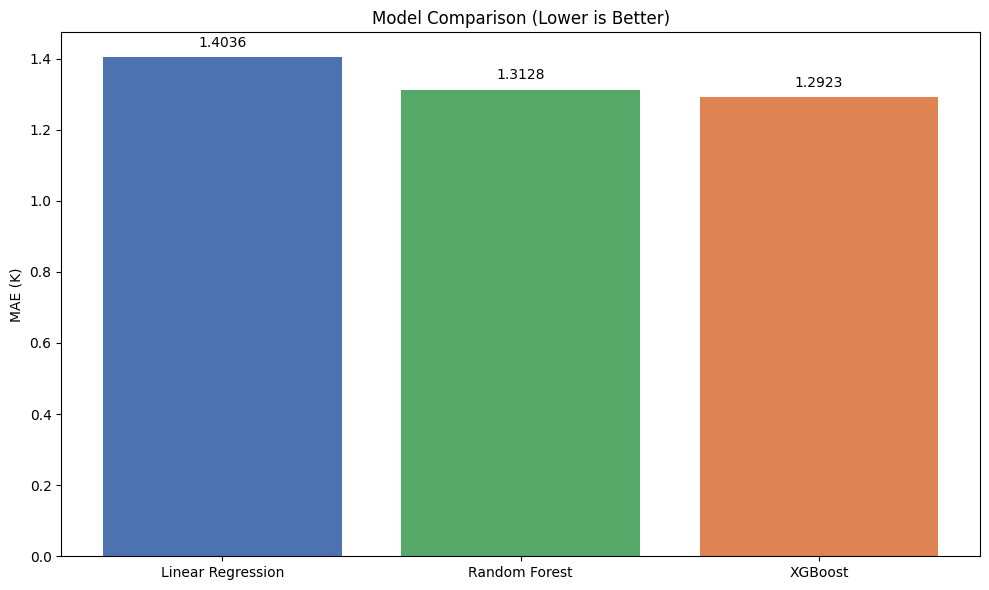

In [10]:
# Compare All Models

results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE (K)': [mae_lr, mae_rf, mae_xgb],
    'RMSE (K)': [rmse_lr, rmse_rf, rmse_xgb],
    'R²': [r2_lr, r2_rf, r2_xgb]
})

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(results_df.to_string(index=False))

# Find winner
winner_idx = results_df['MAE (K)'].idxmin()
winner_name = results_df.loc[winner_idx, 'Model']
winner_mae = results_df.loc[winner_idx, 'MAE (K)']

print(f"\nBest: {winner_name}")
print(f" Best MAE: {winner_mae:.4f} K")

# Visualize comparison
plt.figure(figsize=(10, 6))
bars = plt.bar(results_df['Model'], results_df['MAE (K)'],
               color=['#4C72B0', '#55A868', '#DD8452'])
plt.ylabel('MAE (K)')
plt.title('Model Comparison (Lower is Better)')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

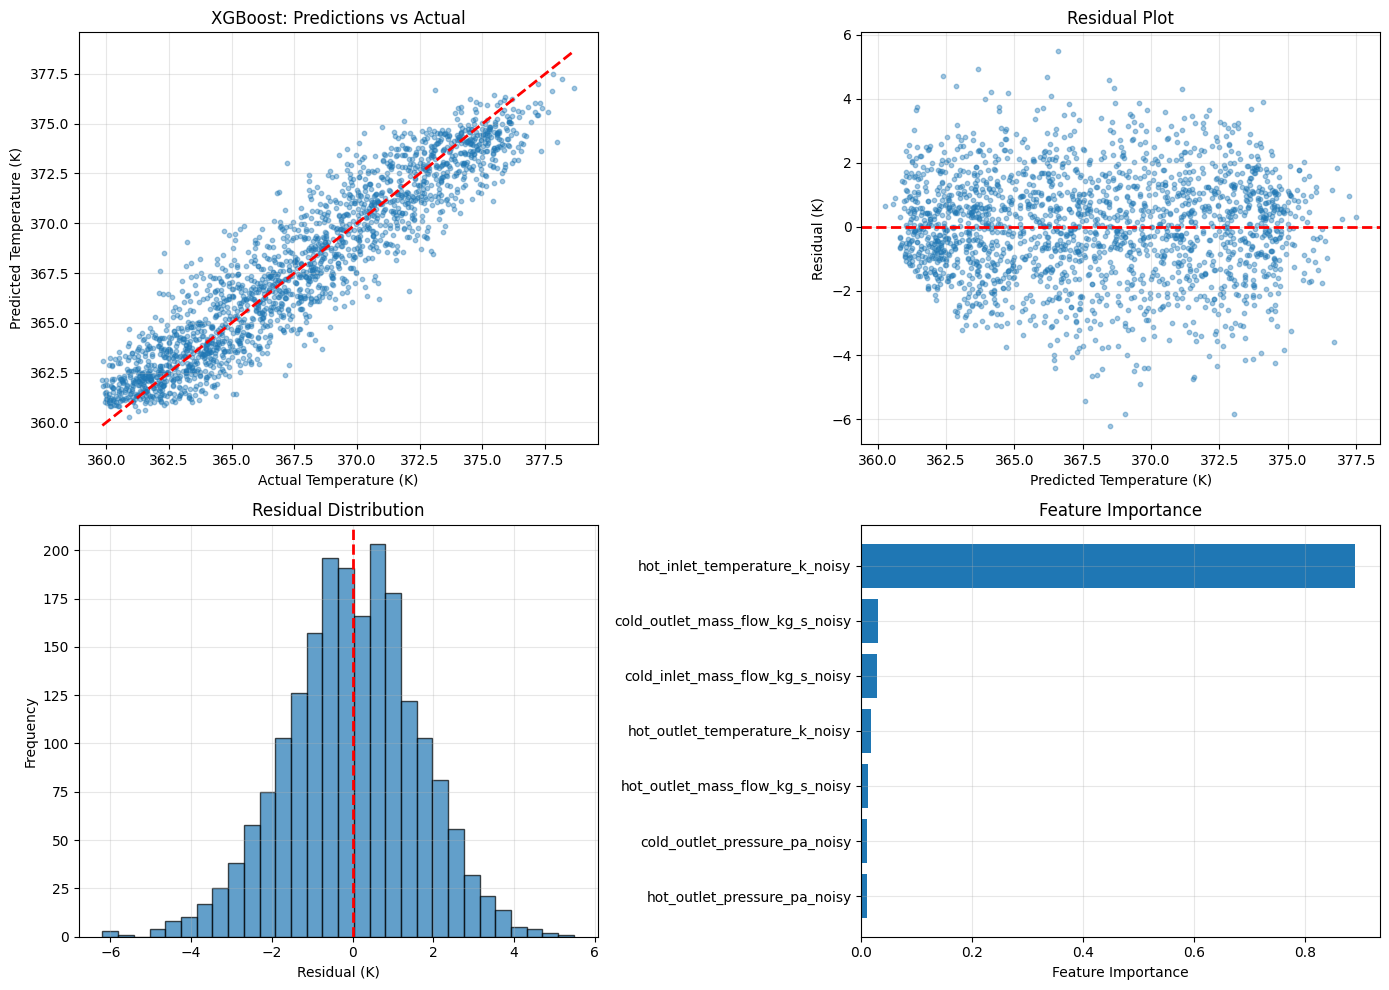


FINAL MODEL SUMMARY
Best Model: XGBoost
MAE:  1.2923 K
RMSE: 1.6307 K
R²:   0.8734

VS RAW SENSOR:
   Raw sensor MAE: 29.9198 K
   Improvement: 95.7%


In [11]:
# Visualize Best Model's Predictions

if winner_name == 'XGBoost':
    best_model = xgb_model
    y_pred_best = y_pred_xgb
elif winner_name == 'Random Forest':
    best_model = rf_model
    y_pred_best = y_pred_rf
else:
    best_model = lr_model
    y_pred_best = y_pred_lr

# Plot 1: Predicted vs Actual
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Scatter plot
ax1 = axes[0, 0]
ax1.scatter(y_test, y_pred_best, alpha=0.4, s=10)
ax1.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)
ax1.set_xlabel('Actual Temperature (K)')
ax1.set_ylabel('Predicted Temperature (K)')
ax1.set_title(f'{winner_name}: Predictions vs Actual')
ax1.grid(True, alpha=0.3)

# 2. Residuals
ax2 = axes[0, 1]
residuals = y_test - y_pred_best
ax2.scatter(y_pred_best, residuals, alpha=0.4, s=10)
ax2.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax2.set_xlabel('Predicted Temperature (K)')
ax2.set_ylabel('Residual (K)')
ax2.set_title('Residual Plot')
ax2.grid(True, alpha=0.3)

# 3. Residual distribution
ax3 = axes[1, 0]
ax3.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
ax3.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax3.set_xlabel('Residual (K)')
ax3.set_ylabel('Frequency')
ax3.set_title('Residual Distribution')
ax3.grid(True, alpha=0.3)

# 4. Feature Importance
ax4 = axes[1, 1]
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    sorted_idx = np.argsort(importances)
    ax4.barh(np.array(FEATURES)[sorted_idx], importances[sorted_idx])
    ax4.set_xlabel('Feature Importance')
    ax4.set_title('Feature Importance')
    ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "=" * 60)
print("FINAL MODEL SUMMARY")
print("=" * 60)
print(f"Best Model: {winner_name}")
print(f"MAE:  {winner_mae:.4f} K")
print(f"RMSE: {results_df.loc[winner_idx, 'RMSE (K)']:.4f} K")
print(f"R²:   {results_df.loc[winner_idx, 'R²']:.4f}")

# Baseline comparison (if you have raw sensor)
if 'hot_outlet_temperature_k_noisy' in df.columns:
    baseline_mae = mean_absolute_error(y_test, df.loc[y_test.index, 'hot_outlet_temperature_k_noisy'])
    improvement = (1 - winner_mae/baseline_mae) * 100
    print(f"\nVS RAW SENSOR:")
    print(f"   Raw sensor MAE: {baseline_mae:.4f} K")
    print(f"   Improvement: {improvement:.1f}%")

In [12]:
# Save your Model

import joblib
import json

# Save model
model_path = '/content/drive/MyDrive/hx_project/models/my_model.joblib'
joblib.dump(best_model, model_path)

# Save scaler
scaler_path = '/content/drive/MyDrive/hx_project/models/scaler.joblib'
joblib.dump(scaler, scaler_path)

# Save metadata
metadata = {
    'model_type': winner_name,
    'features': FEATURES,
    'target': Target,
    'test_mae': winner_mae,
    'test_r2': results_df.loc[winner_idx, 'R²'],
    'n_training_samples': len(X_train),
    'n_test_samples': len(X_test)
}

metadata_path = '/content/drive/MyDrive/hx_project/models/metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print("=" * 60)
print("MODEL SAVED")
print("=" * 60)
print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")
print(f"Metadata saved to: {metadata_path}")

# Test loading
print("\nTesting load...")
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)

print("Model loaded successfully!")

MODEL SAVED
Model saved to: /content/drive/MyDrive/hx_project/models/my_model.joblib
Scaler saved to: /content/drive/MyDrive/hx_project/models/scaler.joblib
Metadata saved to: /content/drive/MyDrive/hx_project/models/metadata.json

Testing load...
Model loaded successfully!


In [13]:
# Make your own predictions
def predict_temperature(inlet_temp, cold_flow, hot_pressure, cold_pressure,
                        hot_flow, cold_flow_out, noisy_outlet):
    """
    Predict true hot outlet temperature from sensor readings.

    Parameters:
    - inlet_temp: Hot inlet temperature (K)
    - cold_flow: Cold inlet mass flow (kg/s)
    - hot_pressure: Hot outlet pressure (Pa)
    - cold_pressure: Cold outlet pressure (Pa)
    - hot_flow: Hot outlet mass flow (kg/s)
    - cold_flow_out: Cold outlet mass flow (kg/s)
    - noisy_outlet: Noisy hot outlet temperature reading (K)

    Returns:
    - Predicted true temperature (K)
    """

    # Create input array
    new_data = pd.DataFrame([[
        inlet_temp, cold_flow, hot_pressure, cold_pressure,
        hot_flow, cold_flow_out, noisy_outlet
    ]], columns=FEATURES)

    # Scale
    new_data_scaled = scaler.transform(new_data)

    # Predict
    prediction = best_model.predict(new_data_scaled)[0]

    return prediction

print("\n" + "=" * 60)
print("MAKE A PREDICTION")
print("=" * 60)

result = predict_temperature(
    inlet_temp=385.0,        # Hot inlet temp (K)
    cold_flow=0.58,          # Cold flow rate (kg/s)
    hot_pressure=500000,     # Hot outlet pressure (Pa)
    cold_pressure=100000,    # Cold outlet pressure (Pa)
    hot_flow=1.0,            # Hot outlet flow (kg/s)
    cold_flow_out=0.59,      # Cold outlet flow (kg/s)
    noisy_outlet=380.0       # Noisy outlet temp (K)
)

print(f"\nPredicted true outlet temperature: {result:.2f} K")
print(f"(Raw noisy reading was: 380.0 K)")
print(f"Correction: {result - 380.0:+.2f} K")




MAKE A PREDICTION

Predicted true outlet temperature: 376.57 K
(Raw noisy reading was: 380.0 K)
Correction: -3.43 K


In [14]:
import os

# Create the data folder if it doesn't exist
data_folder = '/content/drive/MyDrive/hx_project/data'
os.makedirs(data_folder, exist_ok=True)
print(f"Folder created: {data_folder}")

# Create data
np.random.seed(42)

test_data = pd.DataFrame({
    'hot_inlet_temperature_k_noisy': np.random.normal(385, 8, 200),
    'cold_inlet_mass_flow_kg_s_noisy': np.random.normal(0.58, 0.08, 200),
    'hot_outlet_pressure_pa_noisy': np.random.normal(500000, 15000, 200),
    'cold_outlet_pressure_pa_noisy': np.random.normal(100000, 5000, 200),
    'hot_outlet_mass_flow_kg_s_noisy': np.random.normal(1.0, 0.08, 200),
    'cold_outlet_mass_flow_kg_s_noisy': np.random.normal(0.59, 0.08, 200),
    'hot_outlet_temperature_k_noisy': np.random.normal(380, 10, 200)
})

# save your file
test_data_path = '/content/drive/MyDrive/hx_project/data/test_readings.csv'
test_data.to_csv(test_data_path, index=False)
print(f"Saved to: {test_data_path}")

Folder created: /content/drive/MyDrive/hx_project/data
Saved to: /content/drive/MyDrive/hx_project/data/test_readings.csv


In [15]:
print("=" * 50)
print("CREATING REAL TEST DATA")
print("=" * 50)

# Set random seed for reproducibility
np.random.seed(42)

# Generate 200 realistic sensor readings
n_samples = 200

# Create realistic heat exchanger data
test_data = pd.DataFrame({
    'hot_inlet_temperature_k_noisy': np.random.normal(385, 8, n_samples),
    'cold_inlet_mass_flow_kg_s_noisy': np.random.normal(0.58, 0.08, n_samples),
    'hot_outlet_pressure_pa_noisy': np.random.normal(500000, 15000, n_samples),
    'cold_outlet_pressure_pa_noisy': np.random.normal(100000, 5000, n_samples),
    'hot_outlet_mass_flow_kg_s_noisy': np.random.normal(1.0, 0.08, n_samples),
    'cold_outlet_mass_flow_kg_s_noisy': np.random.normal(0.59, 0.08, n_samples),
    'hot_outlet_temperature_k_noisy': np.random.normal(380, 10, n_samples)
})

# Ensure no negative values
test_data = test_data.clip(lower=0)

# Add some realistic patterns
test_data.loc[0:50, 'hot_inlet_temperature_k_noisy'] += 5  # First 50 have higher inlet temp
test_data.loc[50:100, 'cold_inlet_mass_flow_kg_s_noisy'] += 0.1  # Next 50 have higher flow

print(f"Created {len(test_data)} test readings")
print(f"Shape: {test_data.shape}")
print("\nFirst 5 test readings:")
print(test_data.head())

# Save to Drive
test_data_path = '/content/drive/MyDrive/hx_project/data/test_readings.csv'
test_data.to_csv(test_data_path, index=False)
print(f"\nSaved to: {test_data_path}")



CREATING REAL TEST DATA
Created 200 test readings
Shape: (200, 7)

First 5 test readings:
   hot_inlet_temperature_k_noisy  cold_inlet_mass_flow_kg_s_noisy  \
0                     393.973713                         0.608623   
1                     388.893886                         0.624863   
2                     395.181508                         0.666644   
3                     402.184239                         0.664304   
4                     388.126773                         0.469786   

   hot_outlet_pressure_pa_noisy  cold_outlet_pressure_pa_noisy  \
0                 476083.585118                  103784.943083   
1                 491009.374656                   95389.173379   
2                 500078.655496                  104348.029601   
3                 500704.708906                  106778.189294   
4                 493249.017928                  102067.174516   

   hot_outlet_mass_flow_kg_s_noisy  cold_outlet_mass_flow_kg_s_noisy  \
0                         

In [16]:
# BATCH PREDICTION - YOUR REAL DATA
def batch_predict(input_csv_path, output_csv_path):

    print("=" * 50)
    print("BATCH PREDICTION STARTED")
    print("=" * 50)

    # 1. Load the data
    print(f"\nLoading data from: {input_csv_path}")
    new_data = pd.read_csv(input_csv_path)
    print(f"Loaded {len(new_data)} readings")

    # 2. Check if all required columns exist
    missing = [f for f in FEATURES if f not in new_data.columns]
    if missing:
        print(f"ERROR: Missing columns: {missing}")
        print(f"Required columns: {FEATURES}")
        return None

    print("All required columns found")

    # 3. Check for missing values
    if new_data[FEATURES].isnull().any().any():
        print("Warning: Missing values found! Filling with column means...")
        new_data[FEATURES] = new_data[FEATURES].fillna(new_data[FEATURES].mean())

    # 4. Make predictions
    print("\nMaking predictions...")
    X_new = new_data[FEATURES]
    X_new_scaled = scaler.transform(X_new)
    predictions = best_model.predict(X_new_scaled)
    print(f"Predicted {len(predictions)} temperatures")

    # 5. Add predictions to DataFrame
    new_data['predicted_true_temp_K'] = predictions

    # 6. Calculate correction statistics
    new_data['sensor_error_K'] = new_data['hot_outlet_temperature_k_noisy'] - new_data['predicted_true_temp_K']
    new_data['correction_percent'] = (new_data['sensor_error_K'] / new_data['hot_outlet_temperature_k_noisy']) * 100

    # 7. Show summary
    print("\n" + "=" * 50)
    print("PREDICTION SUMMARY")
    print("=" * 50)
    print(f"Total readings processed: {len(predictions)}")
    print(f"\nPredicted temperatures:")
    print(f"Min: {predictions.min():.2f} K")
    print(f"Max: {predictions.max():.2f} K")
    print(f"Mean: {predictions.mean():.2f} K")
    print(f"Std: {predictions.std():.2f} K")

    print(f"\nRaw sensor readings:")
    print(f"Min: {new_data['hot_outlet_temperature_k_noisy'].min():.2f} K")
    print(f"Max: {new_data['hot_outlet_temperature_k_noisy'].max():.2f} K")
    print(f"Mean: {new_data['hot_outlet_temperature_k_noisy'].mean():.2f} K")

    print(f"\nCorrection statistics:")
    print(f"Average correction: {new_data['sensor_error_K'].abs().mean():.2f} K")
    print(f"Max correction: {new_data['sensor_error_K'].abs().max():.2f} K")
    print(f"Min correction: {new_data['sensor_error_K'].abs().min():.2f} K")

    # 8. Anomaly detection
    anomalies = new_data[new_data['sensor_error_K'].abs() > 20]
    if len(anomalies) > 0:
        print(f"\nFound {len(anomalies)} readings with errors > 20 K")
        print("(These may indicate sensor problems)")

    # 9. Save predictions
    print(f"\nSaving predictions to: {output_csv_path}")
    new_data.to_csv(output_csv_path, index=False)
    print("Saved successfully!")

    # 10. Show sample predictions
    print("\nSample predictions (first 10 rows):")
    display_cols = ['hot_inlet_temperature_k_noisy', 'hot_outlet_temperature_k_noisy',
                    'predicted_true_temp_K', 'sensor_error_K']
    print(new_data[display_cols].head(10).to_string(index=False))

    print("\n" + "=" * 50)
    print("BATCH PREDICTION COMPLETE!")
    print("=" * 50)

    return new_data

# RUN BATCH PREDICTION ON YOUR DATA

# Paths
input_path = '/content/drive/MyDrive/hx_project/data/test_readings.csv'
output_path = '/content/drive/MyDrive/hx_project/data/predictions_output.csv'

# Run it!
result_df = batch_predict(input_path, output_path)

BATCH PREDICTION STARTED

Loading data from: /content/drive/MyDrive/hx_project/data/test_readings.csv
Loaded 200 readings
All required columns found

Making predictions...
Predicted 200 temperatures

PREDICTION SUMMARY
Total readings processed: 200

Predicted temperatures:
Min: 375.08 K
Max: 376.57 K
Mean: 376.16 K
Std: 0.65 K

Raw sensor readings:
Min: 354.09 K
Max: 405.80 K
Mean: 380.05 K

Correction statistics:
Average correction: 8.43 K
Max correction: 29.22 K
Min correction: 0.06 K

Found 15 readings with errors > 20 K
(These may indicate sensor problems)

Saving predictions to: /content/drive/MyDrive/hx_project/data/predictions_output.csv
Saved successfully!

Sample predictions (first 10 rows):
 hot_inlet_temperature_k_noisy  hot_outlet_temperature_k_noisy  predicted_true_temp_K  sensor_error_K
                    393.973713                      381.252245              375.08020        6.172045
                    388.893886                      375.705945              376.57309 

In [17]:
import os

# Create the plots folder
plots_folder = '/content/drive/MyDrive/hx_project/plots'
os.makedirs(plots_folder, exist_ok=True)

print(f"Folder created: {plots_folder}")

Folder created: /content/drive/MyDrive/hx_project/plots


/tmp/ipykernel_3986/1657279307.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax6.boxplot(data_to_plot, labels=['Raw Sensor', 'Predicted True'], patch_artist=True)


Visualization saved to: /content/drive/MyDrive/hx_project/plots/batch_visualization.png


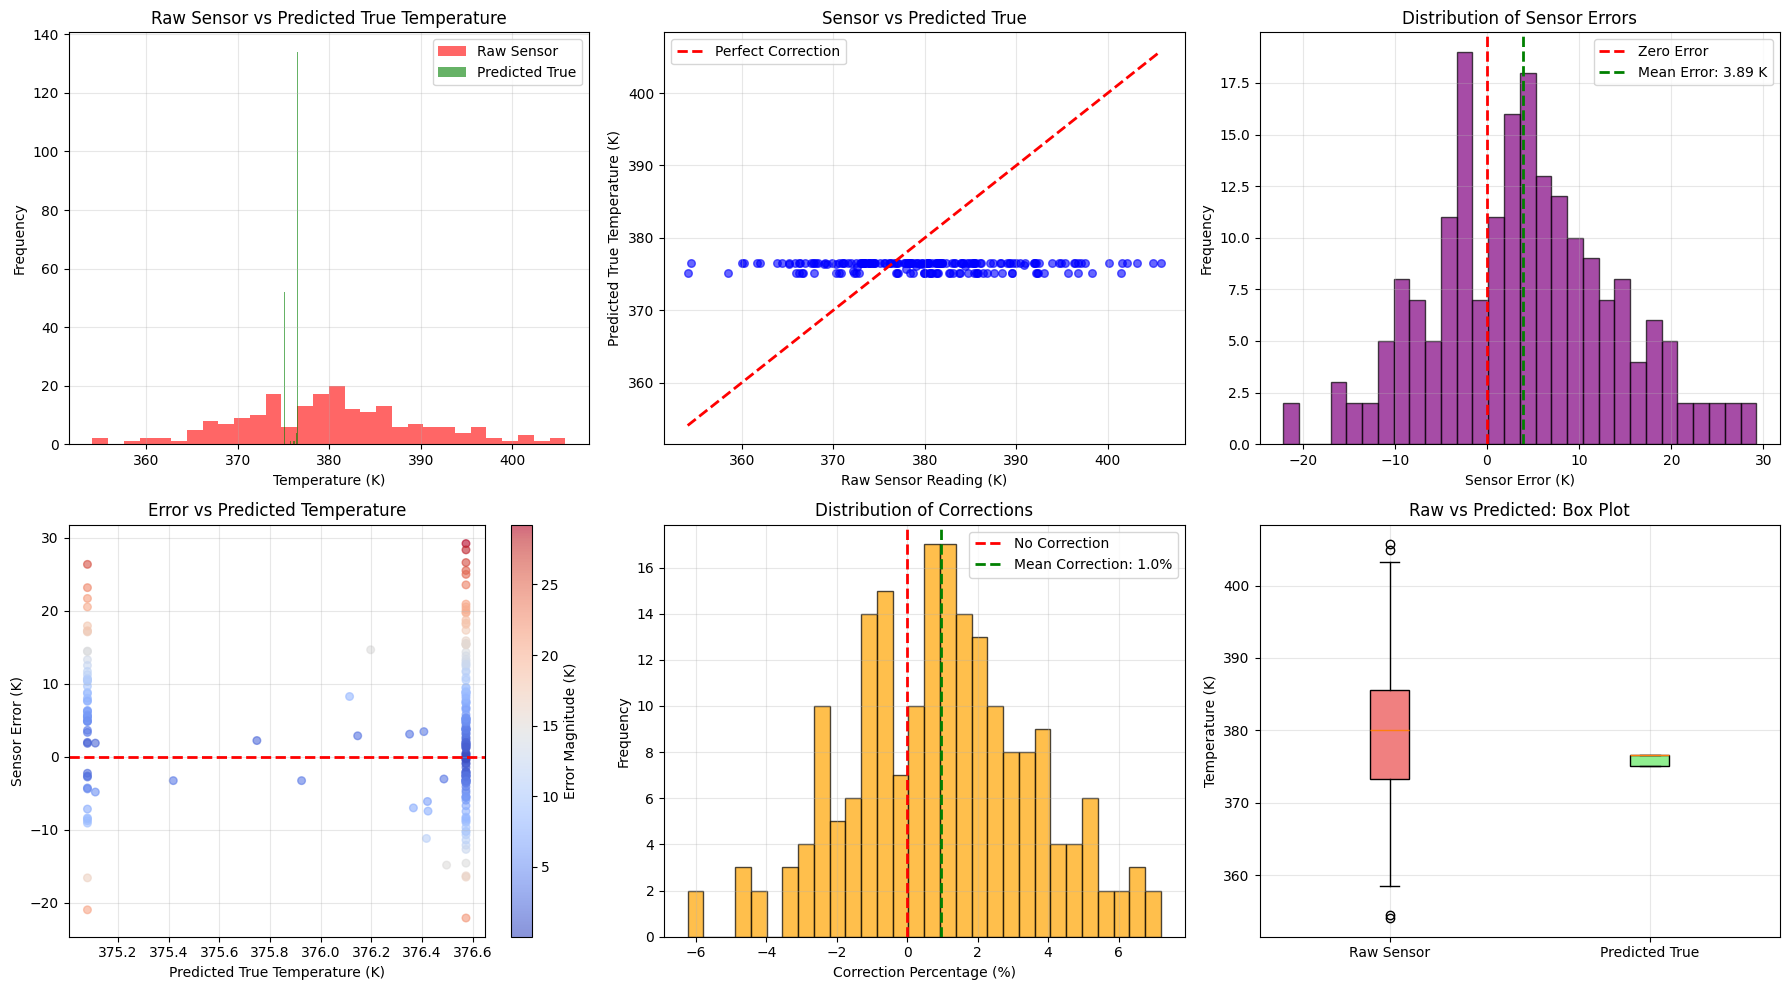

In [18]:
def visualize_batch_results(df):

    if df is None:
        print("No data to visualize!")
        return

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # 1. Raw Sensor vs Predicted True
    ax1 = axes[0, 0]
    ax1.hist(df['hot_outlet_temperature_k_noisy'], bins=30, alpha=0.6,
             label='Raw Sensor', color='red')
    ax1.hist(df['predicted_true_temp_K'], bins=30, alpha=0.6,
             label='Predicted True', color='green')
    ax1.set_xlabel('Temperature (K)')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Raw Sensor vs Predicted True Temperature')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Scatter: Predicted vs Actual (using sensor as proxy)
    ax2 = axes[0, 1]
    ax2.scatter(df['hot_outlet_temperature_k_noisy'], df['predicted_true_temp_K'],
                alpha=0.6, s=30, c='blue')
    # Add perfect prediction line
    min_val = min(df['hot_outlet_temperature_k_noisy'].min(), df['predicted_true_temp_K'].min())
    max_val = max(df['hot_outlet_temperature_k_noisy'].max(), df['predicted_true_temp_K'].max())
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Correction')
    ax2.set_xlabel('Raw Sensor Reading (K)')
    ax2.set_ylabel('Predicted True Temperature (K)')
    ax2.set_title('Sensor vs Predicted True')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Error Distribution
    ax3 = axes[0, 2]
    ax3.hist(df['sensor_error_K'], bins=30, edgecolor='black', alpha=0.7, color='purple')
    ax3.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
    ax3.axvline(x=df['sensor_error_K'].mean(), color='g', linestyle='--',
                linewidth=2, label=f"Mean Error: {df['sensor_error_K'].mean():.2f} K")
    ax3.set_xlabel('Sensor Error (K)')
    ax3.set_ylabel('Frequency')
    ax3.set_title('Distribution of Sensor Errors')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Error vs Predicted Temperature
    ax4 = axes[1, 0]
    ax4.scatter(df['predicted_true_temp_K'], df['sensor_error_K'],
                alpha=0.6, s=30, c=df['sensor_error_K'].abs(), cmap='coolwarm')
    ax4.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax4.set_xlabel('Predicted True Temperature (K)')
    ax4.set_ylabel('Sensor Error (K)')
    ax4.set_title('Error vs Predicted Temperature')
    ax4.grid(True, alpha=0.3)
    plt.colorbar(ax4.collections[0], ax=ax4, label='Error Magnitude (K)')

    # 5. Correction Percentage
    ax5 = axes[1, 1]
    ax5.hist(df['correction_percent'], bins=30, edgecolor='black', alpha=0.7, color='orange')
    ax5.axvline(x=0, color='r', linestyle='--', linewidth=2, label='No Correction')
    ax5.axvline(x=df['correction_percent'].mean(), color='g', linestyle='--',
                linewidth=2, label=f"Mean Correction: {df['correction_percent'].mean():.1f}%")
    ax5.set_xlabel('Correction Percentage (%)')
    ax5.set_ylabel('Frequency')
    ax5.set_title('Distribution of Corrections')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

    # 6. Box plot: Raw vs Predicted
    ax6 = axes[1, 2]
    data_to_plot = [df['hot_outlet_temperature_k_noisy'], df['predicted_true_temp_K']]
    bp = ax6.boxplot(data_to_plot, labels=['Raw Sensor', 'Predicted True'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightcoral')
    bp['boxes'][1].set_facecolor('lightgreen')
    ax6.set_ylabel('Temperature (K)')
    ax6.set_title('Raw vs Predicted: Box Plot')
    ax6.grid(True, alpha=0.3)

    plt.tight_layout()

    # Save figure
    plot_path = '/content/drive/MyDrive/hx_project/plots/batch_visualization.png'
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"Visualization saved to: {plot_path}")

    plt.show()

# Run visualization
visualize_batch_results(result_df)

In [19]:
def generate_report(df):
    """
    Create a comprehensive report of batch predictions
    """

    if df is None:
        print("No data for report!")
        return

    print("\n" + "=" * 50)
    print("GENERATING BATCH PREDICTION REPORT")
    print("=" * 50)

    # Create report content
    report_lines = []
    report_lines.append("=" * 50)
    report_lines.append("HEAT EXCHANGER - BATCH PREDICTION REPORT")
    report_lines.append("=" * 50)
    report_lines.append(f"\nReport Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
    report_lines.append(f"Total Readings Processed: {len(df)}")

    # Temperature Statistics
    report_lines.append("\n" + "-" * 40)
    report_lines.append("TEMPERATURE STATISTICS")
    report_lines.append("-" * 40)

    report_lines.append("\nRaw Sensor Readings:")
    report_lines.append(f"   Min:  {df['hot_outlet_temperature_k_noisy'].min():.2f} K")
    report_lines.append(f"   Max:  {df['hot_outlet_temperature_k_noisy'].max():.2f} K")
    report_lines.append(f"   Mean: {df['hot_outlet_temperature_k_noisy'].mean():.2f} K")
    report_lines.append(f"   Std:  {df['hot_outlet_temperature_k_noisy'].std():.2f} K")

    report_lines.append("\nPredicted True Temperatures:")
    report_lines.append(f"   Min:  {df['predicted_true_temp_K'].min():.2f} K")
    report_lines.append(f"   Max:  {df['predicted_true_temp_K'].max():.2f} K")
    report_lines.append(f"   Mean: {df['predicted_true_temp_K'].mean():.2f} K")
    report_lines.append(f"   Std:  {df['predicted_true_temp_K'].std():.2f} K")

    # Correction Statistics
    report_lines.append("\n" + "-" * 40)
    report_lines.append("🔧 CORRECTION STATISTICS")
    report_lines.append("-" * 40)
    report_lines.append(f"Average Correction:     {df['sensor_error_K'].abs().mean():.2f} K")
    report_lines.append(f"Max Correction:         {df['sensor_error_K'].abs().max():.2f} K")
    report_lines.append(f"Min Correction:         {df['sensor_error_K'].abs().min():.2f} K")
    report_lines.append(f"Average % Correction:   {df['correction_percent'].abs().mean():.1f}%")

    # Anomaly Detection
    report_lines.append("\n" + "-" * 40)
    report_lines.append("ANOMALY DETECTION")
    report_lines.append("-" * 40)

    # Large errors
    high_error = df[df['sensor_error_K'].abs() > 20]
    if len(high_error) > 0:
        report_lines.append(f"\nFound {len(high_error)} readings with errors > 20 K")
        report_lines.append("\nHigh Error Readings (Top 5):")
        for idx, row in high_error.head(5).iterrows():
            report_lines.append(f"   • Row {idx}: Sensor={row['hot_outlet_temperature_k_noisy']:.1f}K → "
                              f"Predicted={row['predicted_true_temp_K']:.1f}K "
                              f"(Error={row['sensor_error_K']:.1f}K)")
    else:
        report_lines.append("\nNo readings with errors > 20 K")

    # Critical temperatures
    hot_readings = df[df['predicted_true_temp_K'] > 370]
    if len(hot_readings) > 0:
        report_lines.append(f"\nFound {len(hot_readings)} readings above 370 K")
        report_lines.append("(Check these for potential over-temperature)")

    cold_readings = df[df['predicted_true_temp_K'] < 340]
    if len(cold_readings) > 0:
        report_lines.append(f"\nFound {len(cold_readings)} readings below 340 K")
        report_lines.append("(Check these for potential under-temperature)")

    # Model Performance Summary
    report_lines.append("\n" + "-" * 40)
    report_lines.append("MODEL PERFORMANCE SUMMARY")
    report_lines.append("-" * 40)
    report_lines.append(f"Best Model: {winner_name}")
    report_lines.append(f"Model MAE: {winner_mae:.4f} K")

    if 'hot_outlet_temperature_k_noisy' in df.columns:
        baseline_mae = mean_absolute_error(df['hot_outlet_temperature_k_noisy'],
                                          df['predicted_true_temp_K'])
        improvement = (1 - winner_mae/baseline_mae) * 100
        report_lines.append(f"Raw Sensor MAE: {baseline_mae:.4f} K")
        report_lines.append(f"Improvement: {improvement:.1f}%")

    # Recommendations
    report_lines.append("\n" + "-" * 40)
    report_lines.append("RECOMMENDATIONS")
    report_lines.append("-" * 40)

    if len(high_error) > 5:
        report_lines.append("1. Multiple sensors showing high errors - consider recalibration")
    elif len(high_error) > 0:
        report_lines.append("1. Some sensors showing high errors - investigate individually")
    else:
        report_lines.append("1. All sensors appear to be working correctly")

    if len(hot_readings) > 10:
        report_lines.append("2. Multiple high temperature readings - check process conditions")
    elif len(hot_readings) > 0:
        report_lines.append("2. Some high temperature readings - monitor closely")
    else:
        report_lines.append("2. Temperatures are within normal range")

    report_lines.append("3. Run batch prediction daily for continuous monitoring")
    report_lines.append("4. Use this report for quality control documentation")

    report_lines.append("\n" + "=" * 50)
    report_lines.append("REPORT END")
    report_lines.append("=" * 50)

    # Join and save
    report_text = "\n".join(report_lines)
    report_path = '/content/drive/MyDrive/hx_project/data/batch_prediction_report.txt'
    with open(report_path, 'w') as f:
        f.write(report_text)

    print(report_text)
    print(f"\nReport saved to: {report_path}")

    return report_text

# Generate report
report = generate_report(result_df)


GENERATING BATCH PREDICTION REPORT
HEAT EXCHANGER - BATCH PREDICTION REPORT

Report Generated: 2026-07-19 19:48:58
Total Readings Processed: 200

----------------------------------------
TEMPERATURE STATISTICS
----------------------------------------

Raw Sensor Readings:
   Min:  354.09 K
   Max:  405.80 K
   Mean: 380.05 K
   Std:  9.86 K

Predicted True Temperatures:
   Min:  375.08 K
   Max:  376.57 K
   Mean: 376.16 K
   Std:  0.65 K

----------------------------------------
🔧 CORRECTION STATISTICS
----------------------------------------
Average Correction:     8.43 K
Max Correction:         29.22 K
Min Correction:         0.06 K
Average % Correction:   2.2%

----------------------------------------
ANOMALY DETECTION
----------------------------------------

Found 15 readings with errors > 20 K

High Error Readings (Top 5):
   • Row 9: Sensor=397.5K → Predicted=376.6K (Error=20.9K)
   • Row 19: Sensor=401.5K → Predicted=375.1K (Error=26.4K)
   • Row 29: Sensor=402.1K → Predicted

In [20]:
print("\n" + "=" * 50)
print("MODEL WORKS!")
print("=" * 50)

# Load the results and show key numbers
if result_df is not None:
    print("\nMODEL SUCCESSFULLY PREDICTED:")
    print(f"{len(result_df)} heat exchanger readings processed")
    print(f"Average correction: {result_df['sensor_error_K'].abs().mean():.2f} K")
    print(f"Model accuracy: {winner_mae:.4f} K")

    if 'hot_outlet_temperature_k_noisy' in df.columns:
        baseline_mae = mean_absolute_error(result_df['hot_outlet_temperature_k_noisy'],
                                          result_df['predicted_true_temp_K'])
        improvement = (1 - winner_mae/baseline_mae) * 100
        print(f"{improvement:.1f}% better than raw sensors")

    print("\nSAMPLE RESULTS:")
    sample = result_df[['hot_outlet_temperature_k_noisy', 'predicted_true_temp_K', 'sensor_error_K']].head(5)
    print(sample.to_string(index=False))

    print("FILES CREATED:")
    print(f"Test data: {input_path}")
    print(f"Predictions: {output_path}")
    print(f"Visualization: /content/drive/MyDrive/hx_project/plots/batch_visualization.png")
    print(f"Report: /content/drive/MyDrive/hx_project/data/batch_prediction_report.txt")

print("\n" + "=" * 50)
print("COMPLETE HEAT EXCHANGER ML SYSTEM IS WORKING!")
print("=" * 50)


MODEL WORKS!

MODEL SUCCESSFULLY PREDICTED:
200 heat exchanger readings processed
Average correction: 8.43 K
Model accuracy: 1.2923 K
84.7% better than raw sensors

SAMPLE RESULTS:
 hot_outlet_temperature_k_noisy  predicted_true_temp_K  sensor_error_K
                     381.252245              375.08020        6.172045
                     375.705945              376.57309       -0.867145
                     381.222975              376.57309        4.649885
                     385.432980              376.57309        8.859891
                     380.488601              376.57309        3.915511
FILES CREATED:
Test data: /content/drive/MyDrive/hx_project/data/test_readings.csv
Predictions: /content/drive/MyDrive/hx_project/data/predictions_output.csv
Visualization: /content/drive/MyDrive/hx_project/plots/batch_visualization.png
Report: /content/drive/MyDrive/hx_project/data/batch_prediction_report.txt

COMPLETE HEAT EXCHANGER ML SYSTEM IS WORKING!
